# EDA Food Access Dataset

# Introduction

This notebook profiles the raw USDA Food Access Research Atlas (FARA) 2019 data —
72,531 census tracts × 147 columns — before aggregating it to the county level
needed to join CDC PLACES, ACS, and CHR&R on `CountyFIPS`. FARA is reported at the
tract level, not the county level, so getting from raw tracts to a clean,
county-level table is most of the work here: diagnosing *why* values are missing
(structural vs. genuine), deciding what to drop versus impute, and validating that
the tract-to-county aggregation preserves population totals and produces
well-bounded shares.

**What this notebook does:**
1. Profile the 147 raw tract-level columns and classify missingness as structural
   (e.g., low-access bands that are blank because no one lives that far from a
   supermarket) or genuine
2. Clean accordingly — drop unusable columns, fill structural zeros, impute
   genuine gaps with state medians
3. Derive `CountyFIPS` from the tract ID and aggregate to the county level
   (population-weighted means for rates/flags, sums for counts)
4. Validate the aggregation and export `Food_Access_County_2019.csv` for the
   merge notebook

# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

# Read The excel file 

In [2]:
base_path = Path.cwd().parents[1]  # Get the parent directory of the current working directory

data_path = base_path / "data" / "raw"/ "FoodAccessResearchAtlasData2019.xlsx"

df = pd.read_excel(data_path, sheet_name="Food Access Research Atlas")

print(f"Data loaded successfully")

Data loaded successfully


# Preview the data

In [3]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nRandom sample:")
display(df.sample(min(5, len(df)), random_state=42))

First 5 rows:


,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,...,TractSeniors,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP
0,1001020100,Alabama,Autauga County,1,1912,693,0,0.0,0.000000,0,...,221.0,1622.0,217.0,14.0,0.0,14.0,45.0,44.0,6.0,102.0
1,1001020200,Alabama,Autauga County,1,2170,743,0,181.0,8.341014,1,...,214.0,888.0,1217.0,5.0,0.0,5.0,55.0,75.0,89.0,156.0
2,1001020300,Alabama,Autauga County,1,3373,1256,0,0.0,0.000000,0,...,439.0,2576.0,647.0,17.0,5.0,11.0,117.0,87.0,99.0,172.0
3,1001020400,Alabama,Autauga County,1,4386,1722,0,0.0,0.000000,0,...,904.0,4086.0,193.0,18.0,4.0,11.0,74.0,85.0,21.0,98.0
4,1001020500,Alabama,Autauga County,1,10766,4082,0,181.0,1.681219,0,...,1126.0,8666.0,1437.0,296.0,9.0,48.0,310.0,355.0,230.0,339.0



Last 5 rows:


,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,...,TractSeniors,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP
72526,56043000200,Wyoming,Washakie County,0,3326,1317,0,57.0,1.713770,0,...,593.0,3106.0,6.0,15.0,0.0,27.0,172.0,309.0,61.0,64.0
72527,56043000301,Wyoming,Washakie County,1,2665,1154,0,10.0,0.375235,0,...,399.0,2377.0,5.0,23.0,0.0,40.0,220.0,446.0,88.0,41.0
72528,56043000302,Wyoming,Washakie County,1,2542,1021,0,73.0,2.871755,0,...,516.0,2312.0,11.0,10.0,1.0,26.0,182.0,407.0,23.0,64.0
72529,56045951100,Wyoming,Weston County,0,3314,1322,0,252.0,7.604104,0,...,499.0,3179.0,15.0,10.0,1.0,47.0,62.0,91.0,47.0,34.0
72530,56045951300,Wyoming,Weston County,1,3894,1699,0,61.0,1.566513,0,...,650.0,3706.0,6.0,10.0,2.0,44.0,126.0,125.0,34.0,110.0



Random sample:


,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,...,TractSeniors,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP
6366,6037536103,California,Los Angeles County,1,5516,1403,0,1.0,0.018129,0,...,412.0,2891.0,42.0,35.0,0.0,68.0,2480.0,5219.0,177.0,270.0
9405,6073009504,California,San Diego County,0,5914,1807,0,45.0,0.760906,0,...,394.0,4067.0,166.0,1268.0,13.0,15.0,385.0,438.0,16.0,11.0
40229,33011025500,New Hampshire,Hillsborough County,0,6235,2475,0,13.0,0.208500,0,...,684.0,6008.0,37.0,36.0,2.0,20.0,132.0,90.0,0.0,150.0
30900,24510240200,Maryland,Baltimore city,1,2564,1358,0,0.0,0.000000,0,...,246.0,2284.0,103.0,108.0,0.0,3.0,66.0,80.0,59.0,35.0
1696,4013104302,Arizona,Maricopa County,1,3209,1713,0,0.0,0.000000,1,...,285.0,2153.0,252.0,137.0,4.0,96.0,567.0,811.0,330.0,252.0


## Check dataset dimensions and columns

In [4]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

Number of rows: 72,531
Number of columns: 147


## Check data types and dataset information

In [5]:
print("Data types:")
display(df.dtypes.to_frame(name="data_type"))

print("\nDataset information:")
df.info()

Data types:


,data_type
CensusTract,int64
State,object
County,object
Urban,int64
Pop2010,int64
...,...
TractAIAN,float64
TractOMultir,float64
TractHispanic,float64
TractHUNV,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72531 entries, 0 to 72530
Columns: 147 entries, CensusTract to TractSNAP
dtypes: float64(126), int64(19), object(2)
memory usage: 81.3+ MB


Because this data is reported at the **census-tract level** while our unit of analysis is the 
**county**, a key step in this notebook is profiling the raw tract-level data before 
aggregating it to the 5-digit FIPS (GEOID) county level used to join our other sources 
(CDC PLACES, ACS, and CHR&R).

**Goals of this EDA:**
1. Profile the 147 raw features and identify which are relevant to hypertension risk modeling
2. Assess missingness, duplicates, and data-grain issues at the tract level
3. Validate the tract-to-county aggregation logic
4. Flag candidate predictors (e.g., food desert density, vehicle access) for the modeling table

## Check dup rows

In [6]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Number of duplicate rows: 0
Duplicate percentage: 0.00%


## Check missing values

In [7]:
# how many columns have missing values
# how many columns have no missing values
num_missing = (df.isnull().sum() > 0).sum()
num_complete = (df.isnull().sum() == 0).sum()

print(f"Columns with missing values : {num_missing}")
print(f"Columns without missing values: {num_complete}")

Columns with missing values : 126
Columns without missing values: 21


We found out there are 126 missing rows and with vaires levels of missing persentage here. We'll using a generic guildeline that handling the missing with different categaries in next steps.

# Handling the missingness
## Creating a missingness table

In [8]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100,
    "Data Type": df.dtypes
})

missing = missing.sort_values("Missing %", ascending=False)
display(missing)

,Missing Count,Missing %,Data Type
lanhopi20,71025,97.923646,float64
lalowi20,71025,97.923646,float64
lanhopi20share,71025,97.923646,float64
laaian20,71025,97.923646,float64
laaian20share,71025,97.923646,float64
...,...,...,...
LATracts_half,0,0.000000,int64
LATracts1,0,0.000000,int64
LATracts10,0,0.000000,int64
LATracts20,0,0.000000,int64


## Missing Value Assessment

The table below summarizes the missing-value assessment and the corresponding preprocessing decisions. These actions serve as the initial data cleaning strategy and may be refined after further exploratory analysis and feature evaluation.

**Missing Value Handling Strategy**

| Check | Result | Decision |
|------|--------|----------|
| No Missing Values | 0% missing | Keep the variable without modification. |
| Low Missingness | < 5% missing | Impute using simple statistical methods (median for numerical variables, mode for categorical variables). |
| Moderate Missingness | 5%–20% missing | Apply statistical imputation and evaluate the variable's predictive contribution. |
| High Missingness | 20%–40% missing | Investigate the pattern and mechanism of missingness before deciding whether to retain or remove the variable. |
| Very High Missingness | 40%–60% missing | Retain only if the variable is clinically or scientifically important; otherwise consider removing it. |
| Extreme Missingness | > 60–70% missing | Remove unless the variable is highly relevant to the study objective or the missingness itself contains useful information. |

**Next Steps.** Generate a missing-value summary, investigate the missingness mechanism (MCAR, MAR, or MNAR), apply appropriate imputation methods, create missing indicators when beneficial, and validate the selected strategy during model development.

In [9]:
missing_pct = df.isnull().mean() * 100

summary = pd.DataFrame({
    "Missing Threshold": ["0%", "<5%", "5–20%", "20–40%", "40–60%", ">60%"],
    "Count": [
        (missing_pct == 0).sum(),
        ((missing_pct > 0) & (missing_pct < 5)).sum(),
        ((missing_pct >= 5) & (missing_pct < 20)).sum(),
        ((missing_pct >= 20) & (missing_pct < 40)).sum(),
        ((missing_pct >= 40) & (missing_pct < 60)).sum(),
        (missing_pct >= 60).sum()
    ]
})

display(summary)

,Missing Threshold,Count
0,0%,21
1,<5%,16
2,5–20%,26
3,20–40%,28
4,40–60%,4
5,>60%,52


We'd like to explore how many missing within each threshold with a barchart. 

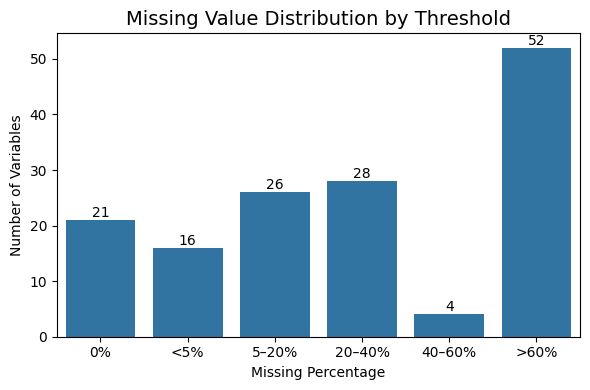

In [10]:
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=summary,
    x="Missing Threshold",
    y="Count"
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Missing Value Distribution by Threshold", fontsize=14)
plt.xlabel("Missing Percentage")
plt.ylabel("Number of Variables")

plt.tight_layout()
plt.show()

In [11]:
missing_pct = df.isnull().mean() * 100

print("0%")
print(missing_pct[missing_pct == 0].index.tolist())

print("\n<5%")
print(missing_pct[(missing_pct > 0) & (missing_pct < 5)].index.tolist())

print("\n5-20%")
print(missing_pct[(missing_pct >= 5) & (missing_pct < 20)].index.tolist())

print("\n20-40%")
print(missing_pct[(missing_pct >= 20) & (missing_pct < 40)].index.tolist())

print("\n40-60%")
print(missing_pct[(missing_pct >= 40) & (missing_pct < 60)].index.tolist())

print("\n>60%")
print(missing_pct[missing_pct >= 60].index.tolist())

0%
['CensusTract', 'State', 'County', 'Urban', 'Pop2010', 'OHU2010', 'GroupQuartersFlag', 'LILATracts_1And10', 'LILATracts_halfAnd10', 'LILATracts_1And20', 'LILATracts_Vehicle', 'HUNVFlag', 'LowIncomeTracts', 'LA1and10', 'LAhalfand10', 'LA1and20', 'LATracts_half', 'LATracts1', 'LATracts10', 'LATracts20', 'LATractsVehicle_20']

<5%
['NUMGQTRS', 'PCTGQTRS', 'PovertyRate', 'MedianFamilyIncome', 'TractLOWI', 'TractKids', 'TractSeniors', 'TractWhite', 'TractBlack', 'TractAsian', 'TractNHOPI', 'TractAIAN', 'TractOMultir', 'TractHispanic', 'TractHUNV', 'TractSNAP']

5-20%
['lapophalf', 'lapophalfshare', 'lalowihalf', 'lalowihalfshare', 'lakidshalf', 'lakidshalfshare', 'laseniorshalf', 'laseniorshalfshare', 'lawhitehalf', 'lawhitehalfshare', 'lablackhalf', 'lablackhalfshare', 'laasianhalf', 'laasianhalfshare', 'lanhopihalf', 'lanhopihalfshare', 'laaianhalf', 'laaianhalfshare', 'laomultirhalf', 'laomultirhalfshare', 'lahisphalf', 'lahisphalfshare', 'lahunvhalf', 'lahunvhalfshare', 'lasnaphalf',

### Step1  Classify the type of missingness
Before deciding how to handle each tier, we need to understand *why* values are missing.
From the Variable Lookup sheet, the low-access variables (`la...1`, `la...10`, `la...20`)
are only populated when a tract actually has population beyond that distance from a
supermarket. A blank therefore means "no low-access population here" (effectively zero),
not "value unknown." We name these **structural** blanks. Everything else (like
`MedianFamilyIncome`) is **genuine** missingness where the true value exists but wasn't
reported.
Evidence for the structural reading: `lapop20share` is blank for 99.9% of urban
tracts (no one in a city lives 20 miles from a supermarket) but populated for rural
ones, while `lapop1share` shows the reverse pattern. The blanks follow geography,
not randomness.

In [12]:
# Structural columns follow the la* naming pattern (low-access distance bands)
structural_cols = [c for c in missing_pct.index if c.lower().startswith('la')]

genuine_cols = [c for c in missing_pct.index
                if c not in structural_cols and missing_pct[c] > 0]

print(f"Structural (la*) columns: {len(structural_cols)}")
print(f"Genuinely missing columns: {len(genuine_cols)}")
print("\nGenuine columns and their missing %:")
print(missing_pct[genuine_cols].sort_values(ascending=False).round(2))

Structural (la*) columns: 118
Genuinely missing columns: 16

Genuine columns and their missing %:
MedianFamilyIncome    1.03
NUMGQTRS              0.03
PCTGQTRS              0.03
TractLOWI             0.01
TractKids             0.01
TractSeniors          0.01
TractWhite            0.01
TractBlack            0.01
TractAsian            0.01
TractNHOPI            0.01
TractAIAN             0.01
TractOMultir          0.01
TractHispanic         0.01
TractHUNV             0.01
TractSNAP             0.01
PovertyRate           0.00
dtype: float64


### Step 2: Cross-check the classification against the threshold tiers

This crosstab confirms that the high-missingness tiers are dominated by structural
la* columns. If a non-structural column ever appears in a high tier, that would be a
genuine data problem worth investigating rather than a pattern to clean mechanically.

In [13]:
check = pd.DataFrame({'pct_missing': missing_pct})

def tier_label(p):
    if p == 0:    return '0%'
    elif p < 5:   return '<5%'
    elif p < 20:  return '5-20%'
    elif p < 40:  return '20-40%'
    elif p < 60:  return '40-60%'
    else:         return '>60%'

check['tier'] = check['pct_missing'].apply(tier_label)
check['structural'] = check.index.isin(structural_cols)

pd.crosstab(check['tier'], check['structural'])

structural,False,True
tier,,
0%,13,8
20-40%,0,28
40-60%,0,4
5-20%,0,26
<5%,16,0
>60%,0,52


Reading the crosstab.** Of the 147 columns, 118 are structural low-access (`la*`)
variables and 29 are non-structural. The pattern is striking: every column with 5%
or more missingness is structural — the False column is zero for all four
mid-to-high tiers. Genuine missingness is confined to 16 non-structural columns in
the <5% tier (e.g., `MedianFamilyIncome`), which we impute with state medians in a
later step.

### Step 3: Columns with more than 60% missing → drop

From the threshold summary, this tier is almost entirely the 10- and 20-mile
low-access variables. These are structurally blank for most of the country, so they
hold very little variance for a national model, and they overlap heavily with the
1-mile and 10-mile families we keep. Our hypothesis centers on the 1/10-mile and
vehicle-access measures, so we drop this 60% tier and record the list.

In [14]:
tier_gt60 = missing_pct[missing_pct >= 60].index.tolist()

df_clean = df.drop(columns=tier_gt60, errors='ignore')

print(f"Dropped {len(tier_gt60)} columns (>60% missing)")
print(f"df_clean shape: {df_clean.shape}")

Dropped 52 columns (>60% missing)
df_clean shape: (72531, 95)


**Why drop instead of fill**: we could fill these with 0 like other structural blanks, but a column that is 98% one value has almost no variance to learn from, and it inflates multicollinearity with its 1- and 10-mile siblings. Removing 52 columns we'd never model is feature selection, and the printed list is our documentation.

### Step 4: Columns with 40–60% missing → case-by-case review

This tier has only a few columns, so instead of one blanket rule I inspect each.
They are still low-access (`la...`) variables — structural blanks — but with enough
coverage to be worth keeping. Since a blank means "no low-access population at this
distance," the correct fill is 0.

In [15]:
tier_40_60 = missing_pct[(missing_pct >= 40) & (missing_pct < 60)].index.tolist()
print("Columns in this tier:", tier_40_60)

# Guardrail: only fill la* columns; anything unexpected stays untouched and visible
la_40_60 = [c for c in tier_40_60 if c.lower().startswith('la') and c in df_clean.columns]
df_clean[la_40_60] = df_clean[la_40_60].fillna(0)
print(f"Filled {len(la_40_60)} structural columns with 0")

Columns in this tier: ['LAPOP1_10', 'LAPOP1_20', 'LALOWI1_10', 'LALOWI1_20']
Filled 4 structural columns with 0


### Step 5: Columns with 20–40% missing → fill structural blanks with 0

This tier is dominated by the 1-mile low-access family (e.g., `lapop1share`, ~28%
missing). The urban/rural cross-check showed these are blank exactly where every
resident lives within 1 mile of a supermarket, so the true value is 0. Mean or
median imputation here would invent low-access populations in dense urban tracts.

In [16]:
tier_20_40 = missing_pct[(missing_pct >= 20) & (missing_pct < 40)].index.tolist()

la_20_40    = [c for c in tier_20_40 if c.lower().startswith('la') and c in df_clean.columns]
other_20_40 = [c for c in tier_20_40 if c not in la_20_40]

df_clean[la_20_40] = df_clean[la_20_40].fillna(0)
print(f"Filled {len(la_20_40)} structural columns with 0")
print("Non-structural columns needing separate review:", other_20_40)

Filled 28 structural columns with 0
Non-structural columns needing separate review: []


### Step 6: Handle the <5% and 5–20% tiers: impute genuine gaps
fill structural with 0, impute genuine gaps

The remaining blanks split into two kinds. Structural `la...` columns in these tiers
get 0, same logic as above. Genuinely missing numeric columns (like
`MedianFamilyIncome`, ~1% missing) are imputed with the **median of their own
state** — income varies strongly by geography, and a national median would drag
every gap toward the middle of the distribution, blurring the regional differences
this project studies.

In [17]:
tier_lt20 = missing_pct[(missing_pct > 0) & (missing_pct < 20)].index.tolist()

la_lt20      = [c for c in tier_lt20 if c.lower().startswith('la') and c in df_clean.columns]
genuine_lt20 = [c for c in tier_lt20 if c not in la_lt20 and c in df_clean.columns]

# Structural → 0
df_clean[la_lt20] = df_clean[la_lt20].fillna(0)

# Genuine numeric → state median
for col in genuine_lt20:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean.groupby('State')[col].transform(
            lambda s: s.fillna(s.median())
        )

print(f"Structural filled with 0: {len(la_lt20)}")
print(f"Imputed with state median: {genuine_lt20}")

Structural filled with 0: 26
Imputed with state median: ['NUMGQTRS', 'PCTGQTRS', 'PovertyRate', 'MedianFamilyIncome', 'TractLOWI', 'TractKids', 'TractSeniors', 'TractWhite', 'TractBlack', 'TractAsian', 'TractNHOPI', 'TractAIAN', 'TractOMultir', 'TractHispanic', 'TractHUNV', 'TractSNAP']


### Step 7: Verify the cleaning

Three checks: (1) no unexplained blanks remain, (2) no rows were lost — cleaning
missingness should never delete tracts, and (3) values that were never blank are
untouched. 

In [18]:
remaining = df_clean.isnull().mean() * 100
print("Columns still containing blanks:", (remaining > 0).sum())
print(remaining[remaining > 0].round(2))

assert len(df_clean) == len(df), "Row count changed!"

check_col = 'PovertyRate'
assert (df[check_col].dropna() ==
        df_clean.loc[df[check_col].notna(), check_col]).all()

print("Row count preserved, spot-check passed.")

Columns still containing blanks: 0
Series([], dtype: float64)
Row count preserved, spot-check passed.


### Step 8: Export the cleaned data and a per-column decision log

The cleaned tract-level file that the county-aggregation notebook will
read as its input, and (2) a CSV logging every column's missing %, threshold tier,
and the action taken. The log makes the cleaning reproducible and provides the
exact numbers cited in the Data Preparation section of our article.

In [19]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72531 entries, 0 to 72530
Data columns (total 95 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CensusTract           72531 non-null  int64  
 1   State                 72531 non-null  object 
 2   County                72531 non-null  object 
 3   Urban                 72531 non-null  int64  
 4   Pop2010               72531 non-null  int64  
 5   OHU2010               72531 non-null  int64  
 6   GroupQuartersFlag     72531 non-null  int64  
 7   NUMGQTRS              72531 non-null  float64
 8   PCTGQTRS              72531 non-null  float64
 9   LILATracts_1And10     72531 non-null  int64  
 10  LILATracts_halfAnd10  72531 non-null  int64  
 11  LILATracts_1And20     72531 non-null  int64  
 12  LILATracts_Vehicle    72531 non-null  int64  
 13  HUNVFlag              72531 non-null  int64  
 14  LowIncomeTracts       72531 non-null  int64  
 15  PovertyRate        

# Aggregation and profile county level

### Step 1: Create the county FIPS code

The tract ID is an 11-digit code: state (2) + county (3) + tract (6). The first 5
digits form the county FIPS, which is the join key for CDC PLACES, ACS, and CHR&R.
The classic bug is leading zeros being dropped on import (Alabama "01001" becoming
"1001"), so I verify the length before slicing.

In [21]:
#df_clean['CensusTract'] = df_clean['CensusTract'].astype(str).str.zfill(11)

df_clean['CountyFIPS'] = df_clean['CensusTract'].str[:5]

print("Tract code lengths:", df_clean['CensusTract'].str.len().unique())  
print("Unique counties:", df_clean['CountyFIPS'].nunique())               # ~3,142

Tract code lengths: [11]
Unique counties: 3142


### Step 2: Tracts per county

County aggregates are built from very different sample sizes — some counties are a
single tract, Los Angeles has ~2,300. This doesn't change the aggregation math, but
it tells us how much to trust small-county values and is worth one figure in the EDA.

In [22]:
tracts_per_county = df_clean.groupby('CountyFIPS').size()
print(tracts_per_county.describe().round(1))
print("\nCounties with a single tract:", (tracts_per_county == 1).sum())

count    3142.0
mean       23.1
std        73.5
min         1.0
25%         3.0
50%         6.0
75%        15.0
max      2334.0
dtype: float64

Counties with a single tract: 239


### Step 3: Classify all columns by aggregation rule

Instead of picking a few variables by hand, I classify all 95 by type:
- **ID columns** (CensusTract, State, County) → not aggregated, used as keys/labels
- **0/1 flags** (Urban, GroupQuartersFlag, LILATracts_*, LA*, HUNVFlag,
  LowIncomeTracts, LATracts*) → population-weighted share
- **Rates and shares** (PovertyRate, MedianFamilyIncome, PCTGQTRS, every column
  ending in "share") → population-weighted mean
- **Everything else** (Pop2010, OHU2010, NUMGQTRS, LAPOP*, LALOWI*, la* counts,
  Tract* counts) → sum, because they are people/housing-unit counts

### Step 3: Define Aggregation rules by variable type

Instead of picking a few variables by hand, I classify all 95 by type:
- **ID columns** (CensusTract, State, County) → not aggregated, used as keys/labels
- **0/1 flags** (Urban, GroupQuartersFlag, LILATracts_*, LA*, HUNVFlag,
  LowIncomeTracts, LATracts*) → population-weighted share
- **Rates and shares** (PovertyRate, MedianFamilyIncome, PCTGQTRS, every column
  ending in "share") → population-weighted mean
- **Everything else** (Pop2010, OHU2010, NUMGQTRS, LAPOP*, LALOWI*, la* counts,
  Tract* counts) → sum, because they are people/housing-unit counts

In [23]:
id_cols = ['CensusTract', 'State', 'County', 'CountyFIPS']

# 0/1 flags: integer columns whose only values are 0 and 1
flag_cols = [c for c in df_clean.columns
             if c not in id_cols
             and df_clean[c].dropna().isin([0, 1]).all()]

# rates/shares: end in "share" or are known rates
rate_cols = [c for c in df_clean.columns if c.endswith('share')]
rate_cols += ['PovertyRate', 'MedianFamilyIncome', 'PCTGQTRS']

# counts: every remaining numeric column
count_cols = [c for c in df_clean.columns
              if c not in id_cols + flag_cols + rate_cols]

print(f"flags: {len(flag_cols)}, rates: {len(rate_cols)}, counts: {len(count_cols)}")
print("\nFlags found:", flag_cols)

flags: 16, rates: 29, counts: 47

Flags found: ['Urban', 'GroupQuartersFlag', 'LILATracts_1And10', 'LILATracts_halfAnd10', 'LILATracts_1And20', 'LILATracts_Vehicle', 'HUNVFlag', 'LowIncomeTracts', 'LA1and10', 'LAhalfand10', 'LA1and20', 'LATracts_half', 'LATracts1', 'LATracts10', 'LATracts20', 'LATractsVehicle_20']


### Step 3: Aggregate tracts to counties

Weighted mean = sum(value × population) / sum(population).
So: multiply each flag/rate by tract population, sum everything by county,
then divide by county population.

In [24]:
temp = df_clean.copy()
weight_cols = flag_cols + rate_cols

# 1) multiply by population
for col in weight_cols:
    temp[col + '_x_pop'] = temp[col] * temp['Pop2010']

# 2) one groupby-sum for everything
sum_cols = count_cols + [c + '_x_pop' for c in weight_cols]
county = temp.groupby('CountyFIPS')[sum_cols].sum()

# 3) divide to finish the weighted means
for col in weight_cols:
    county[col] = county[col + '_x_pop'] / county['Pop2010']
    county = county.drop(columns=col + '_x_pop')

# 4) bring back state and county names
county[['State', 'County']] = df_clean.groupby('CountyFIPS')[['State', 'County']].first()
county = county.reset_index()

print("County table shape:", county.shape)
county.head()

County table shape: (3142, 95)


,CountyFIPS,Pop2010,OHU2010,NUMGQTRS,LAPOP1_10,LAPOP05_10,LAPOP1_20,LALOWI1_10,LALOWI05_10,LALOWI1_20,...,laaian1share,laomultir1share,lahisp1share,lahunv1share,lasnap1share,PovertyRate,MedianFamilyIncome,PCTGQTRS,State,County
0,01001,54571,20221,455.0,18503.225506,29442.469232,13384.295909,7105.688803,10298.758083,4799.665622,...,0.313443,1.651415,1.465841,4.141145,9.101790,15.139879,75759.553774,0.833776,Alabama,Autauga County
1,01003,182265,73180,2307.0,45789.046524,71645.672399,43480.858436,14465.970897,22144.818674,13620.414278,...,0.533662,2.575999,3.124619,2.315064,5.617800,10.947043,73727.425885,1.265739,Alabama,Baldwin County
2,01005,27457,9820,3193.0,5634.362776,8561.996999,992.484005,2864.635946,4453.040884,423.928897,...,0.368560,3.238003,3.800568,6.217392,17.736150,29.341716,45025.706996,11.629093,Alabama,Barbour County
3,01007,22915,7953,2224.0,365.140663,365.140663,0.000000,102.170243,102.170243,0.000000,...,0.228099,1.260497,1.166844,3.852390,8.987988,13.855111,57929.822954,9.705433,Alabama,Bibb County
4,01009,57322,21578,489.0,3902.266075,5431.566187,3902.266075,1440.046734,2038.838706,1440.046734,...,0.473569,4.213784,6.283540,3.458399,8.350675,14.615919,60206.638812,0.853076,Alabama,Blount County


In [25]:
df_clean.head()

,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,...,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP,CountyFIPS
0,01001020100,Alabama,Autauga County,1,1912,693,0,0.0,0.000000,0,...,1622.0,217.0,14.0,0.0,14.0,45.0,44.0,6.0,102.0,01001
1,01001020200,Alabama,Autauga County,1,2170,743,0,181.0,8.341014,1,...,888.0,1217.0,5.0,0.0,5.0,55.0,75.0,89.0,156.0,01001
2,01001020300,Alabama,Autauga County,1,3373,1256,0,0.0,0.000000,0,...,2576.0,647.0,17.0,5.0,11.0,117.0,87.0,99.0,172.0,01001
3,01001020400,Alabama,Autauga County,1,4386,1722,0,0.0,0.000000,0,...,4086.0,193.0,18.0,4.0,11.0,74.0,85.0,21.0,98.0,01001
4,01001020500,Alabama,Autauga County,1,10766,4082,0,181.0,1.681219,0,...,8666.0,1437.0,296.0,9.0,48.0,310.0,355.0,230.0,339.0,01001


### Step 4: Sanity checks

- ~3,142 counties, each FIPS appearing once
- weighted flags must lie between 0 and 1
- total population ≈ 308 million (2010 census) — if not, tracts were lost or double-counted
- no blanks should remain

In [26]:
print("Counties:", len(county))
print("FIPS unique?", county['CountyFIPS'].is_unique)
print("Total population:", f"{county['Pop2010'].sum():,.0f}")
print("Flag range:", county[flag_cols].min().min().round(3),
      "to", county[flag_cols].max().max().round(3))
print("Blanks left:", county.isnull().sum().sum())

Counties: 3142
FIPS unique? True
Total population: 308,745,538
Flag range: 0.0 to 1.0
Blanks left: 0


### Step 5: Re-profile at the county level

A quick distribution check of key variables at the new unit of analysis.
These county-level versions are what enter the model, so this is the level
where EDA on distributions and correlations belongs.

In [27]:
key_vars = ['LILATracts_1And10', 'LILATracts_Vehicle', 'PovertyRate',
            'MedianFamilyIncome', 'lapop1share', 'lahunv1share']

county[key_vars].describe().round(3)

,LILATracts_1And10,LILATracts_Vehicle,PovertyRate,MedianFamilyIncome,lapop1share,lahunv1share
count,3142.000,3142.000,3142.000,3142.000,3142.000,3142.000
mean,0.195,0.185,15.710,64448.733,64.230,3.158
std,0.236,0.236,6.487,16152.747,19.505,3.074
min,0.000,0.000,0.000,21809.222,0.000,0.000
25%,0.000,0.000,11.045,53856.774,51.820,1.621
50%,0.131,0.107,14.874,62376.928,65.879,2.569
75%,0.293,0.278,19.133,71765.942,78.237,3.904
max,1.000,1.000,55.328,176643.465,100.000,54.574


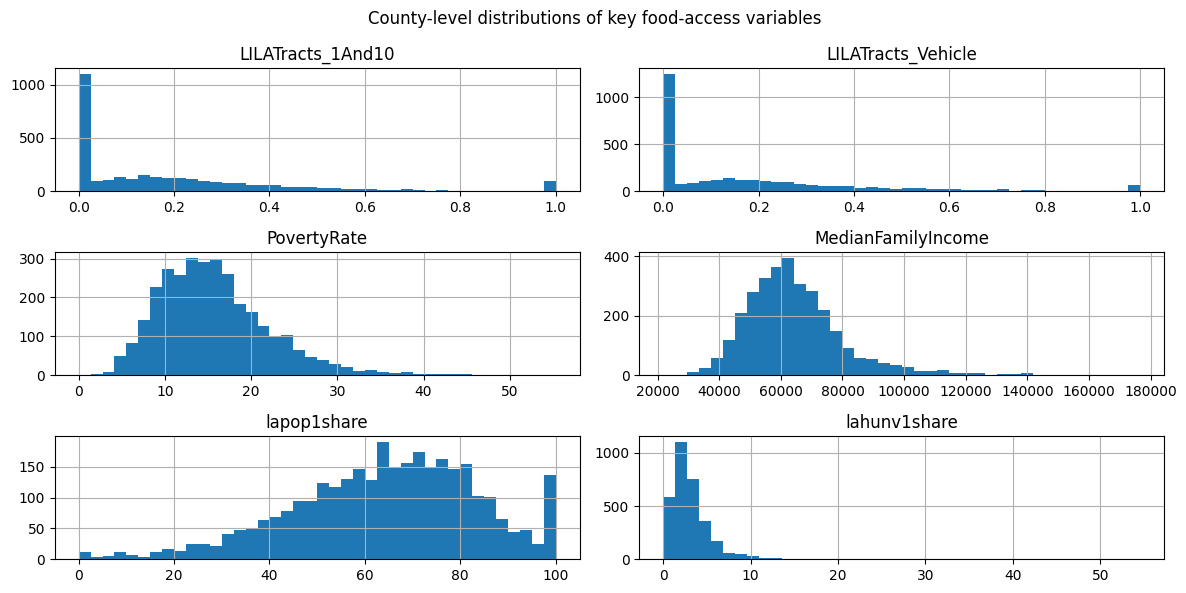

In [28]:
# distributions
county[key_vars].hist(figsize=(12, 6), bins=40)
plt.suptitle("County-level distributions of key food-access variables")
plt.tight_layout()
plt.show()

### Step 6: Save the county-level file

This becomes the Food Access input to the merge notebook, joined to
CDC PLACES, ACS, and CHR&R on CountyFIPS.

In [29]:
out_path = base_path / "data" / "processed" / "Food_Access_County_2019.csv"
county.to_csv(out_path, index=False)
print("Saved:", county.shape, "->", out_path)

Saved: (3142, 95) -> /Users/nancywalker/Documents/University_SanDiego/ADS-599-CapstoneProject/ADS599_Capstone_Hypertension_Risk_Atlas/data/processed/Food_Access_County_2019.csv


# Generate Summary Statistics

In [30]:
county.describe().T

,count,mean,std,min,25%,50%,75%,max
Pop2010,3142.0,98264.015913,312946.532351,82.000000,11114.500000,25872.000000,66780.000000,9.818605e+06
OHU2010,3142.0,37147.133036,111990.961293,39.000000,4368.750000,10017.000000,25829.000000,3.241204e+06
NUMGQTRS,3142.0,2541.320656,6512.642079,0.000000,177.000000,602.000000,2247.000000,1.716820e+05
LAPOP1_10,3142.0,21836.847305,53888.547401,0.000000,1676.936831,4633.860692,15154.992856,7.949477e+05
LAPOP05_10,3142.0,49043.293293,154886.432377,0.000000,2243.623297,7406.767184,26790.299266,3.616488e+06
...,...,...,...,...,...,...,...,...
lahunv1share,3142.0,3.158420,3.073844,0.000000,1.621473,2.568756,3.903581,5.457440e+01
lasnap1share,3142.0,7.968445,5.482790,0.000000,3.936016,6.744132,10.951861,4.209545e+01
PovertyRate,3142.0,15.710278,6.487052,0.000000,11.045149,14.873728,19.133087,5.532839e+01
MedianFamilyIncome,3142.0,64448.732716,16152.747387,21809.221589,53856.774368,62376.927987,71765.942337,1.766435e+05


# Findings and Output

| Check | Result | Decision |
|---|---|---|
| Raw shape | 72,531 tracts × 147 columns | USDA FARA 2019 — the largest of the four source datasets |
| Duplicate rows | 0 (0.00%) | No action |
| Missingness diagnosis | 118 of 147 columns are structural `la*` low-access-distance bands; only 16 columns have genuine missingness, all <5% | Structural blanks filled with 0; genuine gaps imputed with the state median |
| Columns dropped | 52 columns >60% missing (10- and 20-mile low-access bands) | Low variance and redundant with the 1-mile/vehicle measures kept for modeling |
| Cleaned shape | `df_clean`: 72,531 rows × 95 columns, 0 blanks remaining | Row count and previously-populated values verified unchanged |
| County FIPS derived | `CountyFIPS` = first 5 digits of `CensusTract` → 3,142 unique counties | Matches the join key used by CDC PLACES, ACS, and CHR&R |
| Tracts per county | Median 6, mean 23.1, range 1–2,334; 239 single-tract counties | Small counties get little within-county averaging — worth flagging for modeling |
| Aggregation rule | 16 flags + 29 rates → population-weighted mean; 47 counts → summed | `sum(value × pop) / sum(pop)` for flags/rates; direct sum for counts |
| Aggregation sanity check | 3,142 unique FIPS; total population 308,745,538 (≈ actual 2010 Census: 308.7M); all flags bounded [0, 1]; 0 blanks | Aggregation validated — safe to use downstream |
| Output file | `data/processed/Food_Access_County_2019.csv`, 3,142 rows × 95 columns | Ready as the Food Access input to the merge notebook, joined on `CountyFIPS` |

**Selected county-level variables** (from the `describe()` above):

| Variable | Mean | Std | Min–Max |
|---|---|---|---|
| `LILATracts_1And10` (food-desert tract share) | 19.5% | 23.6% | 0–100% |
| `LILATracts_Vehicle` (low-access + no-vehicle share) | 18.5% | 23.6% | 0–100% |
| `PovertyRate` | 15.7% | 6.5% | 0–55.3% |
| `MedianFamilyIncome` | \$64,449 | \$16,153 | \$21,809–\$176,643 |

**Next steps.** Join `Food_Access_County_2019.csv` to CDC PLACES, ACS, and CHR&R on
`CountyFIPS` in the merge notebook; decide whether single-tract counties need
special handling (e.g., a minimum-tract-count flag) before modeling.